## DDIM inversion (initalise with MCPL pretrained)

In [3]:
import sys
sys.path.append('../')
from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from diffusers.utils import load_image
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
from causal_modules import Causal_SCM_v3
from diffusers import DDIMInverseScheduler, DDIMScheduler
from tqdm import tqdm
device = torch.device("cuda")
# Sample function (regular DDIM)
@torch.no_grad()
def sample(
    pipe,
    prompt,
    start_step=0,
    start_latents=None,
    guidance_scale=3.5,
    num_inference_steps=30,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=None,
    intervention_indx=None,
    intervention_values=None,
):
    if guidance_scale>1:
        do_classifier_free_guidance = True
    else:
        do_classifier_free_guidance= False    

    # Encode prompt
    text_embeddings,negtive_prompt_embedding = pipe.encode_prompt(
        prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt
    )
    if do_classifier_free_guidance:
        text_embeddings = torch.cat([negtive_prompt_embedding, text_embeddings])
    # Set num inference steps
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    # Create a random starting point if we don't have one already
    if start_latents is None:
        start_latents = torch.randn(1, 4, 32, 32, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma

    latents = start_latents.clone()

    for i in tqdm(range(start_step, num_inference_steps)):

        t = pipe.scheduler.timesteps[i]

        # Expand the latents if we are doing classifier free guidance
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

        (down_block_res_samples, mid_block_res_sample),causal_loss = pipe.controlnet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=text_embeddings,
                    controlnet_cond=controlnet_image,
                    return_dict=False,
                    label = torch.ones((latent_model_input.size(0),4)),
                    training=False,
                    sampling=False,
                    intervention_indx=intervention_indx,
                    intervention_values=intervention_values,
                    
        )
        
        # Predict the noise residual
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings,
                    down_block_additional_residuals=down_block_res_samples,
                    mid_block_additional_residual=mid_block_res_sample,
                    return_dict=False)[0]



        # Perform guidance
        if do_classifier_free_guidance:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # Normally we'd rely on the scheduler to handle the update step:
        # latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
        #latents = pipe.scheduler.step(noise_pred, t, latents, return_dict=False)[0]
        # Instead, let's do it ourselves:
        prev_t = max(1, t.item() - (1000 // num_inference_steps))  # t-1
        alpha_t = pipe.scheduler.alphas_cumprod[t.item()]
        alpha_t_prev = pipe.scheduler.alphas_cumprod[prev_t]
        predicted_x0 = (latents - (1 - alpha_t).sqrt() * noise_pred) / alpha_t.sqrt()
        direction_pointing_to_xt = (1 - alpha_t_prev).sqrt() * noise_pred
        latents = alpha_t_prev.sqrt() * predicted_x0 + direction_pointing_to_xt

    # Post-processing
    images = pipe.vae.decode(latents/ pipe.vae.config.scaling_factor,return_dict=False)[0]
    do_denormalize = [True] * images.shape[0]
    image = pipe.image_processor.postprocess(images,do_denormalize=do_denormalize)

    return image

## Inversion
@torch.no_grad()
def invert(
    pipe,
    start_latents,
    prompt,
    guidance_scale=3.5,
    num_inference_steps=80,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=None,
    intervention_indx=None,
    intervention_values=None,
):
    
    if guidance_scale>1:
        do_classifier_free_guidance = True
    else:
        do_classifier_free_guidance= False    
    # Encode prompt
    text_embeddings,negtive_prompt_embedding = pipe.encode_prompt(
        prompt, device, num_images_per_prompt, do_classifier_free_guidance, negative_prompt
    )
    if do_classifier_free_guidance:
        text_embeddings = torch.cat([negtive_prompt_embedding, text_embeddings])
    
    # Create a random starting point if we don't have one already
    if start_latents is None:
        start_latents = torch.randn(1, 4, 32, 32, device=device)
        start_latents *= pipe.scheduler.init_noise_sigma
    
    # Latents are now the specified start latents
    latents = start_latents.clone()

    # We'll keep a list of the inverted latents as the process goes on
    intermediate_latents = []

    # Set num inference steps
    pipe.scheduler.set_timesteps(num_inference_steps, device=device)

    # Reversed timesteps <<<<<<<<<<<<<<<<<<<<
    timesteps = reversed(pipe.scheduler.timesteps)

    for i in tqdm(range(1, num_inference_steps), total=num_inference_steps - 1):

        # We'll skip the final iteration
        if i >= num_inference_steps - 1:
            continue

        t = timesteps[i]

        # Expand the latents if we are doing classifier free guidance
        latent_model_input = torch.cat([latents] * 2) if do_classifier_free_guidance else latents
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

        (down_block_res_samples, mid_block_res_sample),causal_loss = pipe.controlnet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=text_embeddings,
                    controlnet_cond=controlnet_image,
                    return_dict=False,
                    label = torch.ones((latent_model_input.size(0),4)),
                    training = False,
                    sampling=False,
                    intervention_indx=intervention_indx,
                    intervention_values=intervention_values,
                    
        )
        # Predict the noise residual
        '''think should I use the control residual here?'''
        noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings,down_block_additional_residuals=down_block_res_samples,
                    mid_block_additional_residual=mid_block_res_sample,
                    return_dict=False)[0]
        #noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=text_embeddings, return_dict=False)[0]
        

        # Perform guidance
        if guidance_scale>1:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        current_t = max(0, t.item() - (1000 // num_inference_steps))  # t
        next_t = t  # min(999, t.item() + (1000//num_inference_steps)) # t+1
        alpha_t = pipe.scheduler.alphas_cumprod[current_t]
        alpha_t_next = pipe.scheduler.alphas_cumprod[next_t]

        # Inverted update step (re-arranging the update step to get x(t) (new latents) as a function of x(t-1) (current latents)
        latents = (latents - (1 - alpha_t).sqrt() * noise_pred) * (alpha_t_next.sqrt() / alpha_t.sqrt()) + (
            1 - alpha_t_next
        ).sqrt() * noise_pred

        # Store
        intermediate_latents.append(latents)

    return torch.cat(intermediate_latents)



def save_images_grid(images_list, grid_size, save_path=None):
    """
    Save a list of lists of images in a grid format.

    Parameters:
    - images_list: List of lists containing numpy images (4x4).
    - grid_size: tuple (grid_rows, grid_cols) for arranging images in the grid.
    - save_path: file path where the grid image will be saved.
    """
    # Flatten the list of lists into a single list of images

    images = [np.asarray(img) for sublist in images_list for img in sublist]

    # Determine the dimensions of the first image to set up the grid
    H, W, C = images[0].shape
    grid_rows, grid_cols = grid_size

    # Check if the grid can fit all images
    assert grid_rows * grid_cols >= len(images), "Grid size is too small for the number of images"

    # Create an empty array for the grid image
    grid_image = np.zeros((grid_rows * H, grid_cols * W, C), dtype=images[0].dtype)

    # Fill the grid with images
    for idx, img in enumerate(images):
        row = idx // grid_cols
        col = idx % grid_cols
        grid_image[row * H:(row + 1) * H, col * W:(col + 1) * W, :] = img

    # Plot and save the grid image
    plt.figure(figsize=(grid_cols, grid_rows))
    plt.imshow(grid_image)
    plt.axis('off')  # Turn off axis labels


In [4]:
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager
from diffusers.models.modeling_utils import load_state_dict
size = 256

image_transforms = transforms.Compose(
        [
            transforms.CenterCrop(128),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.CenterCrop(128),
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
            ]
        )

def load_mcpl_embeddings(base_model_path,tokenizer,embedding_path,presudo_token_ids):
    text_encoder = CLIPTextModel.from_pretrained(
        base_model_path, subfolder="text_encoder"
    )

    state_dict = load_state_dict(embedding_path)
    embeddings = []
    tokens = []
    for key,embed in state_dict.items():
        tokens.append(key)
        embeddings.append(embed)
    token_ids = tokenizer.encode(tokens, add_special_tokens=False)
    # 7.4 Load token and embedding
    for token_id, embedding in zip(token_ids, embeddings):
        # add tokens and get ids
        # tokenizer.add_tokens(token)
        # token_id = tokenizer.convert_tokens_to_ids(token)
        text_encoder.get_input_embeddings().weight.data[token_id] = embedding
        print(f"Loaded textual inversion embedding for {token_id}.")


    embed_proj_path  = embedding_path.replace("learned_embeds", "embeds_proj")
        
    if os.path.exists(embed_proj_path):
        embedding_manager = EmbeddingManager(presudo_token_ids)
        text_encoder.text_model.embeddings.set_embedding_manager(embedding_manager)
        linear_state_dict = load_state_dict(embed_proj_path)
        embedding_manager.embed_proj.load_state_dict(linear_state_dict)
        embedding_manager.eval()
    text_encoder.eval()
    return text_encoder





In [5]:
'''Load pipeline'''
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer

base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


controlnet_path = "../logs/logs_celeA_data100/2025-01-24T11-04-10-controlnet_intial_mcplall/controlnet-steps-30000.safetensors"
mcpl_embedding_path = "../logs/logs_celeA_data100/2025-01-24T11-04-10-controlnet_intial_mcplall/learned_embeds-steps-30000.safetensors"

controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
A_matrix = torch.tensor([[0, 0, 1, 1], [0, 0, 1, 1], [0, 0, 0, 0], [0, 0, 0, 0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.set_A_martix(A_matrix)
controlnet.eval()

# Load mcpl embedding
prompt = "a bald young people with beard"
presudo_words= 'a,bald,young,people,with,beard'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
#pipe.enable_model_cpu_offload()
pipe = pipe.to(device)

Loaded textual inversion embedding for 320.
Loaded textual inversion embedding for 14875.
Loaded textual inversion embedding for 9052.
Loaded textual inversion embedding for 1047.
Loaded textual inversion embedding for 593.
Loaded textual inversion embedding for 1888.


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f

In [11]:
'''from training set'''
import random
import pandas as pd
def dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_datasets/celeA/sampling_100'):
    # name like sampling_100 , sampling_500 dir
    select_columns = ['Young', 'Male', 'Bald', 'No_Beard']
    dataset_id = data_root.split('/')[-1].split('_')[-1]
    root_parent = os.path.dirname(data_root)
    csv_path = os.path.join(root_parent,'meta_'+dataset_id+'.csv')
    df = pd.read_csv(csv_path)
    img_names =np.asarray(df.image_id)
    image_paths = [os.path.join(data_root, file_path) for file_path in img_names]
    label_list = np.asarray(df[select_columns])
    
    img_id = random.randint(0,len(image_paths))
    print(image_paths[img_id])
    print(label_list[img_id])

    return image_paths[img_id],label_list[img_id]

In [12]:
img_path,labels = dataset_load_path()

/home/jovyan/fcvm-data-volume/kzzr229/workspace/causal_datasets/celeA/sampling_100/037793.jpg
[ 1  1 -1  1]


  0%|          | 0/69 [00:00<?, ?it/s]

100%|██████████| 70/70 [00:03<00:00, 20.21it/s]


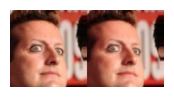

In [16]:


image = Image.open(img_path)
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = transforms.CenterCrop(128)(original_img)
original_img = transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR)(original_img)
condition_image = image.copy()
image = image_transforms(image) 
condition_image = conditioning_image_transforms(condition_image)


# generate image
generator = torch.manual_seed(0)

# embed_name = mcpl_embedding_path.split('/')[-2]
# output = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/outputs/control_edit/{}".format(embed_name)
# os.makedirs(output, exist_ok=True)
# save_path = os.path.join(output,'recons.png')

with torch.no_grad():
    latent = pipe.vae.encode(image.unsqueeze(0).to(device))
    img_latent = 0.18215 * latent.latent_dist.sample()

device = torch.device("cuda")
set_guidance_scale  = 1
num_steps = 70
inverted_latents = invert(pipe,
    img_latent,
    prompt,
    guidance_scale=set_guidance_scale,
    num_inference_steps=num_steps,
    num_images_per_prompt=1,
    negative_prompt="",
    device=device,
    controlnet_image=condition_image.unsqueeze(0).to(device),
    intervention_indx=None,
    intervention_values=None,)
    
s_step = 0
final_im = sample(
        pipe,
        prompt,
        start_step=s_step,
        #start_latents=None,
        start_latents=inverted_latents[-(s_step + 1)][None],
        guidance_scale=set_guidance_scale,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt="",
        device=device,
        controlnet_image=condition_image.unsqueeze(0).to(device),
        intervention_indx=None,
        intervention_values=None,
    )[0]

to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im]],(1,2),None)

In [17]:
def do_intervention(inter_id,inter_value):
    s_step = 0
    interved_image = sample(
                pipe,
                prompt,
                start_step=s_step,
                #start_latents=None,
                start_latents=inverted_latents[-(s_step + 1)][None],
                guidance_scale=set_guidance_scale,
                num_inference_steps=num_steps,
                num_images_per_prompt=1,
                negative_prompt="",
                device=device,
                controlnet_image=condition_image.unsqueeze(0).to(device),
                intervention_indx=inter_id,
                intervention_values=inter_value,
            )[0]

    return interved_image

def direct_effect(inter_img,ori_img):
    image1 = inter_img.convert("L")  # Convert to grayscale
    image2 = ori_img.convert("L")  # Convert to grayscale

    # Convert images to NumPy arrays
    array1 = np.array(image1, dtype=np.float32)
    array2 = np.array(image2, dtype=np.float32)

    # # Compute the direct effect (pixel-wise subtraction)
    direct_effect =-(array1 - array2)
    
    # # Normalize the result for visualization (optional)
    #direct_effect_normalized = direct_effect / np.max(np.abs(direct_effect))  # Normalize to [-1, 1]
    # direct_effect_normalized = (direct_effect-direct_effect.min())/(direct_effect.max()-direct_effect.min())
    # direct_effect_normalized = direct_effect_normalized*2-1
    # # Overlay the direct effect on the original image
    # blended = array2 + 0.5 * direct_effect_normalized  # No need for [..., None] here
    # blended = np.clip(blended, 0, 255)  # Clip values to valid pixel range for images
    return direct_effect

# Do intervention (sex, age ,diease)
direct_effect_recons = direct_effect(final_im,original_img)

cf_img_list = [original_img, final_im]
residual_map_list=[None,direct_effect_recons]

for i in range(4):
    cf_label=-1*labels[i]
    cf_img = do_intervention(i, cf_label)
    residual_map = direct_effect(cf_img, original_img)
    cf_img_list.append(cf_img)
    residual_map_list.append(residual_map)


  0%|          | 0/70 [00:00<?, ?it/s]

100%|██████████| 70/70 [00:03<00:00, 19.94it/s]


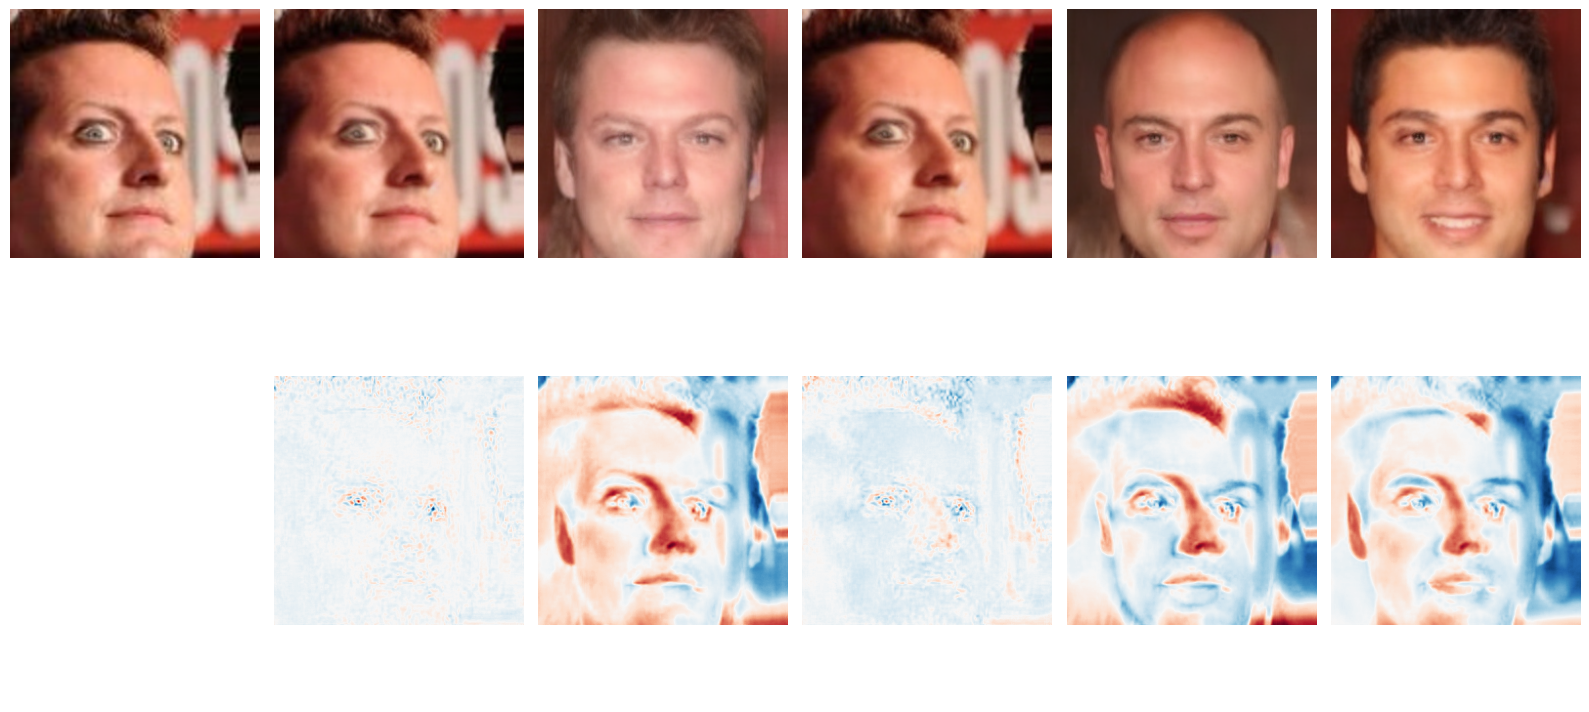

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_results(interved_images, direct_effects):
    """
    Function to plot the original, reconstructed, intervention images and direct effects.
    """
    fig, axes = plt.subplots(2, len(interved_images), figsize=(16, 8))

    # Row 1: Original, Final, Interventions (Sex, Age)
    images_row1 = interved_images
    # titles_row1 = ["Original Image", "Final Image", "Intervention (Sex)", "Intervention (Age)"]

    for i, img in enumerate(images_row1):
        axes[0, i].imshow(np.array(img), cmap="gray")
        
        axes[0, i].axis("off")

    # Row 2: Direct Effects
    images_row2 = direct_effects
    

    for i, img in enumerate(images_row2):
        if img is not None:
            lim = np.absolute(img).max()
            axes[1, i].imshow(img, cmap='RdBu', clim=[-lim, lim])
        
        axes[1, i].axis("off")

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()


# Plot results
plot_results(cf_img_list, 
             residual_map_list)


100%|██████████| 100/100 [00:05<00:00, 19.99it/s]


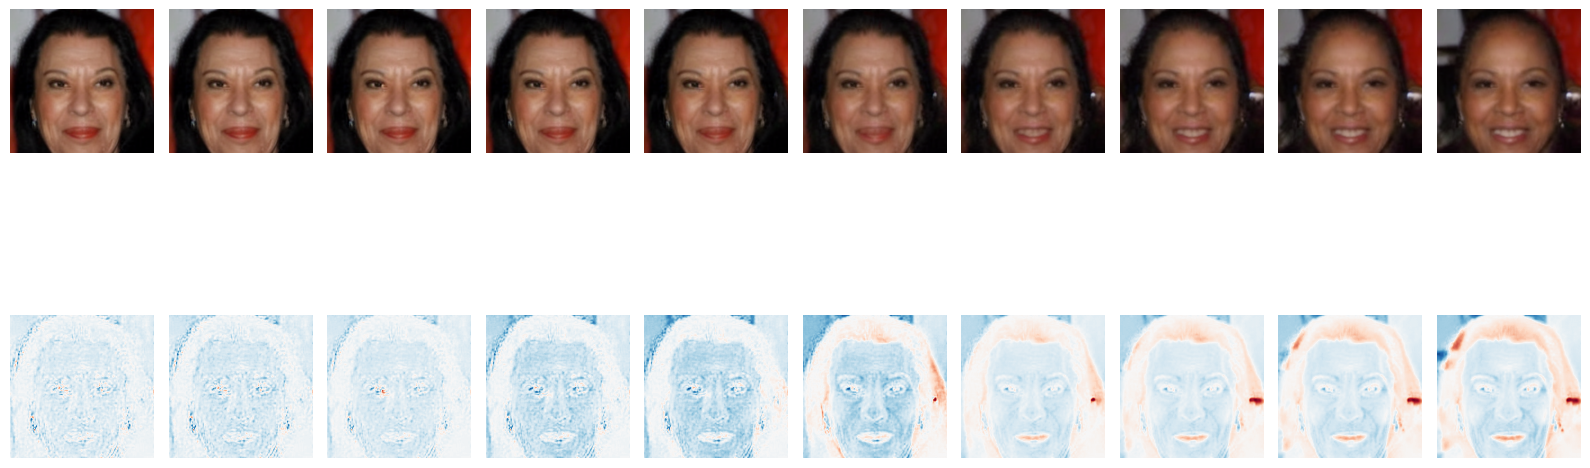

In [57]:
# traverse edit disease 
inter_image_age_list = []
direct_effect_age_list = []
intial_value = -0.8
for i in range(10):
    a_value = intial_value
    
    inter_image_age = do_intervention(2,a_value)
    direct_effect_age = direct_effect(inter_image_age,original_img)
    inter_image_age_list.append(inter_image_age)
    direct_effect_age_list.append(direct_effect_age)
    intial_value+=0.2
plot_results(inter_image_age_list, 
             direct_effect_age_list)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Example Data
# Replace these with your actual data arrays
num_columns = 6
image_size = (256, 256)

# Generate placeholder data
counterfactuals = [np.random.rand(*image_size) for _ in range(num_columns)]  # Counterfactual images
direct_effects = [np.random.rand(*image_size) * 2 - 1 for _ in range(num_columns)]  # Direct effects (-1 to 1)
uncertainties = [np.random.rand(*image_size) for _ in range(num_columns)]  # Uncertainty maps (0 to 1)

# Plotting
fig, axes = plt.subplots(3, num_columns, figsize=(18, 9), constrained_layout=True)

# Titles for each column (replace with meaningful ones)
titles = [
    "do(MRI Seq.=T2)", "do(Age=71)", "do(Sex=female)",
    "do(Brain Vol.=1397.7)", "do(Ventricle Vol.=152.9)", "Null Intervention"
]

# Loop over columns
for col in range(num_columns):
    # Counterfactual
    axes[0, col].imshow(counterfactuals[col], cmap="gray")
    axes[0, col].set_title(titles[col], fontsize=10)
    axes[0, col].axis("off")
    
    # Direct Effect
    im = axes[1, col].imshow(direct_effects[col], cmap="coolwarm", vmin=-1, vmax=1)
    axes[1, col].axis("off")
    if col == num_columns - 1:  # Add colorbar to the last column
        fig.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04, orientation='vertical')

    # Uncertainty
    im = axes[2, col].imshow(uncertainties[col], cmap="viridis", vmin=0, vmax=1)
    axes[2, col].axis("off")
    if col == num_columns - 1:  # Add colorbar to the last column
        fig.colorbar(im, ax=axes[2, col], fraction=0.046, pad=0.04, orientation='vertical')

# Set row labels
axes[0, 0].set_ylabel("Counterfactual", fontsize=12, labelpad=20)
axes[1, 0].set_ylabel("Direct Effect", fontsize=12, labelpad=20)
axes[2, 0].set_ylabel("Uncertainty", fontsize=12, labelpad=20)

plt.show()


In [2]:
import torch
from safetensors import safe_open

# Path to the .safetensors file

repo_id = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_pendulum_img96/2024-11-11T16-15-50-mcpl-all_controlv2_initial_mcpl_notrain/learned_embeds-steps-7000.safetensors"
# Open and load the safetensors file into a state_dict
def load_safetensor_as_state_dict(safetensor_path):
    state_dict = {}

    # Load the tensors using safe_open
    with safe_open(safetensor_path, framework="pt") as f:  # "pt" means PyTorch
        for key in f.keys():
            state_dict[key] = f.get_tensor(key)
            
    return state_dict

# Example usage
state_dict1 = load_safetensor_as_state_dict(repo_id)
# print(state_dict1['red</w>'])

state_dict2 = load_safetensor_as_state_dict('../logs/logs_pendulum_img96/2024-11-11T16-15-50-mcpl-all_controlv2_initial_mcpl_notrain/learned_embeds-steps-10000.safetensors')
# print(state_dict2['red</w>'])

#state_dict3 = load_safetensor_as_state_dict("../logs/2024-10-25T08-56-05-mcpl-all_controlv2_initial_mcpl/learned_embeds-steps-5000.safetensors")
#print(state_dict3)
# Load the state_dict into your model
# Assuming you have a PyTorch model defined as `model`
# model.load_state_dict(state_dict)
state_dict1['red</w>'] == state_dict2['red</w>']

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

In [ ]:
from safetensors import safe_open
with safe_open("../logs/2024-10-22T15-32-14-mcpl-all_control_initial_mcpl_False/controlnet-steps-10000.safetensors/diffusion_pytorch_model.safetensors", framework="pt",device='cuda:0') as f:
    
    print([k for k in f.keys() if 'rep_emb' in k])
    # tensor_slice = f.get_slice('controlnet_cond_embedding.causal_scm.dag.A')
    # print(tensor_slice[:,:])
    print( f.get_slice('controlnet_cond_embedding.causal_scm.rep_emb.fc_var.weight').get_shape())

# Confusion Matrix

In [3]:
from safetensors import safe_open
with safe_open("../logs/2024-11-01T12-52-47-mcpl-all_controlv2_initial_mcpl_train_A_train/controlnet-steps-10000.safetensors/diffusion_pytorch_model.safetensors", framework="pt",device='cuda:0') as f:
    
    print([k for k in f.keys() if 'rep_emb' in k])
    tensor_slice = f.get_slice('controlnet_cond_embedding.A')
    print(tensor_slice[:,:])
    # print(tensor_slice[:,:])
    #print( f.get_slice('controlnet_cond_embedding.causal_scm.rep_emb.fc_var.weight').get_shape())

[]
tensor([[0.0020, 0.9021, 0.9021, 0.9022],
        [0.9021, 0.0035, 0.9021, 0.9022],
        [0.9021, 0.9021, 0.0022, 0.9021],
        [0.9021, 0.9022, 0.9021, 0.0041]], device='cuda:0')


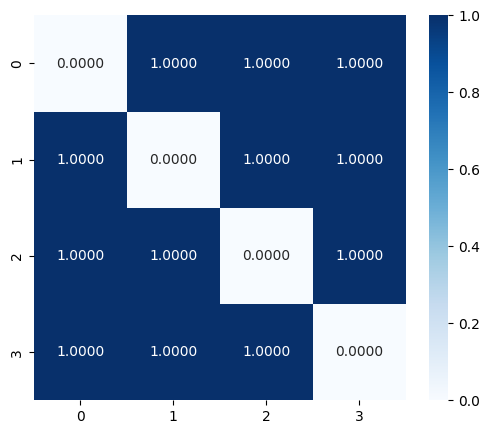

In [6]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# Define the matrix
matrix = torch.tensor([
    [0, 1,1,1],
    [1, 0, 1,1],
    [1, 1, 0, 1],
    [1, 1,1, 0]
], device='cpu')  # Move tensor to CPU for visualization

# Plot the matrix as a confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(matrix.cpu().numpy(), annot=True, fmt=".4f", cmap="Blues", cbar=True)
# plt.title("Confusion Matrix Visualization")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
plt.show()
